# Importing Packages and Modules

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder

# Constants

In [2]:
PATH_SEP = os.sep

# Colour palette used consistently across all visualisations
BLUE = '#636efa'
PINK = '#ef5564'

## **Loading Env**

In [3]:
# Load the .env file
load_dotenv()

True

# Loading Dataframe

In [4]:
folder_path=os.getenv("CLEAN_DATA_FOLDER")
file_name='renewal_clean.csv'
file_path=folder_path+PATH_SEP+file_name
renewal_calls=pd.read_csv(file_path,keep_default_na=False)
# Loading Dataframe
folder_path=os.getenv("CLEAN_DATA_FOLDER")
file_name='emails_clean.csv'
file_path=folder_path+PATH_SEP+file_name
emails=pd.read_csv(file_path,keep_default_na=False)
# Ensure Co_Ref is string in both DataFrames before merging
renewal_calls['Co_Ref'] = renewal_calls['Co_Ref'].astype(str)
emails['Co_Ref'] = emails['Co_Ref'].astype(str)

merged_df = pd.merge(renewal_calls, emails, on='Co_Ref', how='left')

print(f'Shape of renewal_calls_df : {renewal_calls.shape}')
print(f'Shape of emails           : {emails.shape}')
print(f'Shape of merged_df        : {merged_df.shape}')

display(merged_df.head())

Shape of renewal_calls_df : (35839, 25)
Shape of emails           : (37963, 27)
Shape of merged_df        : (35839, 51)


,Co_Ref,Total_Calls_In_Window,Call_Date,desire_to_cancel_clean,Customer_Reaction_Category,Customer_Asked_For_Justification,Membership_Renewal_Decision,Explicit_Switching_Intent,mid_price_log,mid_price_log_flag,...,crm_agent_chased_contractor,crm_accreditation_issues,crm_membership_overdue,crm_auto_renewal_status,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned
0,AA0584,2,2024-05-01,Not Discussed,Not Mentioned,N/A,N/A,N/A,,1,...,No,No,Not Discussed,0,No,No,No,No,No,Not Discussed
1,AA0641,3,2024-11-11,Not Discussed,Not Mentioned,N/A,N/A,N/A,,1,...,No,Not Discussed,Not Discussed,0,Not Discussed,No,No,No,Not Discussed,Not Discussed
2,AA0784,3,2026-01-16,Not Discussed,Not Mentioned,No,No,No,,1,...,Yes,No,No,0,No,No,No,No,No,No
3,AA0794,7,2025-10-16,Not Discussed,Not Mentioned,No,No,No,,1,...,Yes,Not Discussed,Yes,0,Not Discussed,No,No,No,No,No
4,AA0882,1,2025-09-01,Renew,Not Mentioned,No,No,No,,1,...,Yes,Yes,Not Discussed,0,Not Discussed,No,No,No,No,Not Discussed


# Column Description

### 1. Primary Keys & Target Variable
| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| **`Co_Ref`** | Object (String) | Unique customer/contractor identifier used as the primary key for merging and deduplication. |
| **`Prospect_Outcome`** | Object (String) | **[TARGET]** The actual renewal outcome (e.g., Won, Churned). Used as the dependent variable. |

### 2. CRM Behavioural & Operational Flags
| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| **`crm_membership_overdue`** | Object (String) | Indicates whether the customer's membership payment is overdue at the time of the call. |
| **`crm_customer_complained`** | Object (String) | Flag indicating whether the customer raised a complaint during CRM interactions. |
| **`crm_delays_in_accreditation`** | Integer (int64) | **[Engineered]** Binary flag: 1 if any delays, incomplete progress, or outstanding accreditation issues were identified. |
| **`crm_contractor_engagement`** | Integer (int64) | **[Engineered]** Binary flag: 1 if the contractor shows low or disengaged behaviour. |
| **`crm_customer_payment_intention`** | Integer (int64) | **[Engineered]** Binary flag: 1 if the customer showed reluctance or dissatisfaction regarding payment or renewal price. |
| **`crm_dissatisfaction_with_support`** | Integer (int64) | **[Engineered]** Binary flag: 1 if any dissatisfaction, financial hardship, or negative experience was recorded. |
| **`crm_agent_chase_flag`** | Integer (int64) | **[Engineered]** Binary flag: 1 if the agent chased the contractor more than twice, indicating active follow-up pressure. |

### 3. Competitor & Financial Signals
| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| **`crm_competitors_mentioned`** | Object (String) | Whether any competitor was mentioned by the customer during the CRM interaction. |
| **`crm_refund_mentioned`** | Object (String) | Indicates whether a refund was brought up during the interaction. |
| **`crm_financial_hardship_mentioned`** | Object (String) | Flags if the customer mentioned financial difficulty as a reason for potential cancellation. |

### 4. Contractor & Accreditation Details
| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| **`crm_contractor_sentiment_score`** | Object / Numeric | Sentiment score attributed to the contractor based on CRM notes. |
| **`crm_contractor_suggested_leave`** | Object (String) | Whether the contractor has indicated they may leave. |
| **`crm_accreditation_completed`** | Object (String) | Whether the contractor has completed their accreditation process. |
| **`crm_progress_towards_accreditation`** | Object (String) | The contractor's recorded progress towards completing accreditation requirements. |
| **`crm_timely_completion`** | Object (String) | Whether the contractor completes work in a timely manner. |
| **`crm_agent_chased_contractor`** | Object (String) | Whether the agent has actively chased the contractor for responses or documentation. |
| **`crm_agent_chase_count`** | Numeric | Number of times the agent chased the contractor within the interaction window. |

### 5. Renewal Timing
| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| **`Time_to_Renewal`** | Object (String) | Categorical bucket indicating how far in advance of renewal the customer interaction occurred. |

# Data Cleaning

In [12]:
# Replace NaN, empty strings, and null-like values in object columns with 'Not Discussed'
object_cols = merged_df.select_dtypes(include='object').columns

for col in object_cols:
    merged_df[col] = merged_df[col].replace(
        [np.nan, '', 'none', 'None', 'nan'], 'Not Discussed', regex=False
    )

print('Null values after handling blanks in object columns:')
print(merged_df[object_cols].isnull().sum())

display(merged_df.head())

C:\Users\ilakk\AppData\Local\Temp\ipykernel_20252\3860846075.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = merged_df.select_dtypes(include='object').columns


Null values after handling blanks in object columns:
Co_Ref                                  0
Call_Date                               0
desire_to_cancel_clean                  0
Customer_Reaction_Category              0
Customer_Asked_For_Justification        0
Membership_Renewal_Decision             0
Explicit_Switching_Intent               0
mid_price_log                           0
Discussion_on_Price_Increase            0
Discount_Offered                        0
Serious_Complaint                       0
Other_Complaint                         0
Agent_Renewal_Initiation                0
Agent_Response_Category                 0
Discount_or_Waiver_Requested            0
Prospect_Outcome                        0
Time_to_Renewal                         0
crm_accreditation_completed             0
crm_timely_completion                   0
crm_progress_towards_accreditation      0
crm_delays_in_accreditation             0
crm_contractor_suggested_leave          0
crm_contractor_engageme

,Co_Ref,Total_Calls_In_Window,Call_Date,desire_to_cancel_clean,Customer_Reaction_Category,Customer_Asked_For_Justification,Membership_Renewal_Decision,Explicit_Switching_Intent,mid_price_log,mid_price_log_flag,...,crm_agent_chased_contractor,crm_accreditation_issues,crm_membership_overdue,crm_auto_renewal_status,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned
0,AA0584,2,2024-05-01,Not Discussed,Not Mentioned,N/A,N/A,N/A,Not Discussed,1,...,No,No,Not Discussed,0,No,No,No,No,No,Not Discussed
1,AA0641,3,2024-11-11,Not Discussed,Not Mentioned,N/A,N/A,N/A,Not Discussed,1,...,No,Not Discussed,Not Discussed,0,Not Discussed,No,No,No,Not Discussed,Not Discussed
2,AA0784,3,2026-01-16,Not Discussed,Not Mentioned,No,No,No,Not Discussed,1,...,Yes,No,No,0,No,No,No,No,No,No
3,AA0794,7,2025-10-16,Not Discussed,Not Mentioned,No,No,No,Not Discussed,1,...,Yes,Not Discussed,Yes,0,Not Discussed,No,No,No,No,No
4,AA0882,1,2025-09-01,Renew,Not Mentioned,No,No,No,Not Discussed,1,...,Yes,Yes,Not Discussed,0,Not Discussed,No,No,No,No,Not Discussed


# Helper Functions

## Cramer's V — Measuring Association Strength
Cramer's V quantifies the **strength of association** between two categorical variables, normalised between **0** and **1**:

- **V < 0.1** → Negligible association — statistically significant but not useful for modelling.
- **V ≥ 0.1** → Moderate, practically relevant association.
- **V ≥ 0.3** → Strong association — high predictive value.

By computing Cramer's V alongside the chi-square p-value, we distinguish between features that are *statistically* significant due to large sample sizes and those that are *practically* meaningful for churn prediction.

In [13]:
def cramers_v(x, y):
    """Compute Cramer's V for two categorical Series."""
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    phi2_corrected = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corrected = r - ((r - 1) ** 2) / (n - 1)
    k_corrected = k - ((k - 1) ** 2) / (n - 1)
    if min(k_corrected, r_corrected) == 0:
        return 0.0
    return np.sqrt(phi2_corrected / min(k_corrected, r_corrected))

# Feature Engineering

Before hypothesis testing, several raw CRM columns are combined into binary engineered features. Each feature captures a meaningful behavioural pattern that a single raw column would miss.

| Engineered Feature | Source Columns | Logic |
| :--- | :--- | :--- |
| `crm_delays_in_accreditation` | delays, completed, progress | Any sign of accreditation friction |
| `crm_contractor_engagement` | suggested_leave, engagement | Contractor disengaged or likely to leave |
| `crm_customer_payment_intention` | price dissatisfaction, payment intention | Financial reluctance around renewal |
| `crm_agent_chase_flag` | chased, chase_count | Agent chased contractor more than twice |
| `crm_dissatisfaction_with_support` | dissatisfaction, hardship, negative experience | Any support-related complaint signal |

In [14]:
# 1. Accreditation delay feature
merged_df['crm_delays_in_accreditation'] = (
    (merged_df['crm_delays_in_accreditation'].isin(['Yes', 'Not Discussed'])) |
    (merged_df['crm_accreditation_completed'].isin(['Not Discussed', 'No'])) |
    (merged_df['crm_progress_towards_accreditation'].isin(['Not Discussed', 'No']))
).astype(int)

# 2. Contractor engagement feature
merged_df['crm_contractor_engagement'] = (
    (merged_df['crm_contractor_suggested_leave'] == 'Yes') |
    (merged_df['crm_contractor_engagement'].isin(['No', 'Not Discussed']))
).astype(int)

# 3. Customer payment intention feature
merged_df['crm_customer_payment_intention'] = (
    (merged_df['crm_dissatisified_with_renewal_price'] == 'Yes') |
    (merged_df['crm_customer_payment_intention'] == 'No')
).astype(int)

# 4. Agent chase feature
merged_df['crm_agent_chase_flag'] = (
    (merged_df['crm_agent_chased_contractor'] == 'Yes') &
    (merged_df['crm_agent_chase_count'].fillna(0) > 2)
).astype(int)

# 5. Support dissatisfaction feature
merged_df['crm_dissatisfaction_with_support'] = (
    (merged_df['crm_dissatisfaction_with_support'] == 'Yes') |
    (merged_df['crm_financial_hardship_mentioned'] == 'Yes') |
    (merged_df['crm_negative_customer_experience'] == 'Yes')
).astype(int)

print('Engineered feature value counts:')
for feat in ['crm_delays_in_accreditation', 'crm_contractor_engagement',
             'crm_customer_payment_intention', 'crm_agent_chase_flag',
             'crm_dissatisfaction_with_support']:
    print(f'\n{feat}:')
    print(merged_df[feat].value_counts())

Engineered feature value counts:

crm_delays_in_accreditation:
crm_delays_in_accreditation
1    35004
0      835
Name: count, dtype: int64

crm_contractor_engagement:
crm_contractor_engagement
1    18999
0    16840
Name: count, dtype: int64

crm_customer_payment_intention:
crm_customer_payment_intention
0    33378
1     2461
Name: count, dtype: int64

crm_agent_chase_flag:
crm_agent_chase_flag
0    31634
1     4205
Name: count, dtype: int64

crm_dissatisfaction_with_support:
crm_dissatisfaction_with_support
0    33365
1     2474
Name: count, dtype: int64


# **Testing The Hypothesis**

# Feature Selection Strategy: Moving Beyond P-Values

## The Problem: The "Large Sample Size Trap"
When working with large datasets, traditional hypothesis testing that relies purely on **p-values** creates a critical risk: even a microscopic, practically meaningless difference between groups will produce a "highly significant" result simply because the math becomes hyper-sensitive at scale.

A p-value only answers: *"Does a mathematical difference exist?"* — not *"Is this difference large enough to matter?"*

## The Solution: Cramer's V Effect Size
To ensure only robust, practically meaningful features are selected for modelling, our pipeline ranks variables using **Cramer's V (effect size)** alongside the chi-square p-value.

| Cramer's V Range | Interpretation |
|:---|:---|
| **V < 0.1** | Negligible — statistically significant but not useful |
| **0.1 ≤ V < 0.3** | Moderate — worth investigating |
| **V ≥ 0.3** | Strong — high predictive value |

### Conclusion for Modelling
By ranking features by **Cramer's V** rather than the p-value alone, we avoid feeding the model noise, reduce dimensionality, and protect against overfitting on trivially small differences inflated by sample size.

# **Hypothesis 1: Membership Overdue → Higher Churn**

**H₀:** There is no association between membership overdue status and churn.  
**Hₐ:** Customers with an overdue membership are more likely to churn.

Contingency Table:
Prospect_Outcome        Churned    Won
crm_membership_overdue                
No                         1118   8440
Not Discussed              5024  16534
Yes                         766   3957

Chi-squared = 606.08 | p-value = 2.4632e-132 | Cramer's V = 0.0918
Conclusion: Reject H₀ — significant association found.


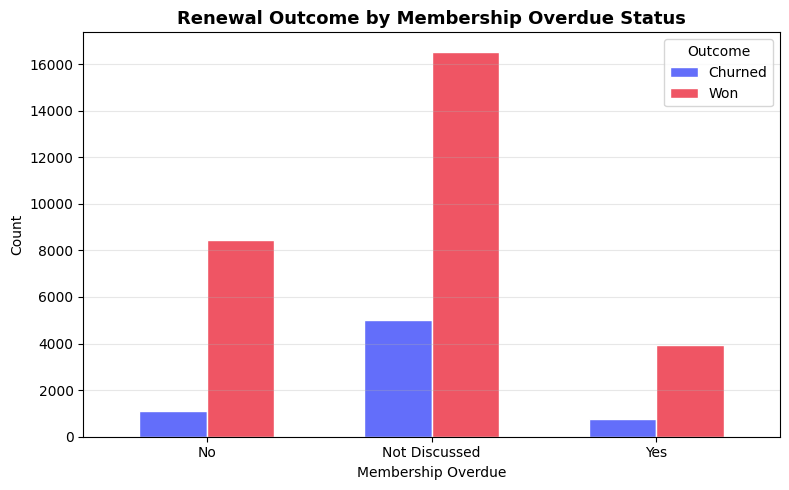

In [15]:
col = 'crm_membership_overdue'
ct = pd.crosstab(merged_df[col], merged_df['Prospect_Outcome'])
chi2, p_value, _, _ = chi2_contingency(ct)
v = cramers_v(merged_df[col], merged_df['Prospect_Outcome'])

print('Contingency Table:')
print(ct)
print(f'\nChi-squared = {chi2:.2f} | p-value = {p_value:.4e} | Cramer\'s V = {v:.4f}')
print('Conclusion:', 'Reject H₀ — significant association found.' if p_value < 0.05 else 'Fail to reject H₀.')

# Grouped bar chart (count-based)
fig, ax = plt.subplots(figsize=(8, 5))
ct.plot(kind='bar', ax=ax, color=[BLUE, PINK], edgecolor='white', width=0.6)
ax.set_title('Renewal Outcome by Membership Overdue Status', fontweight='bold', fontsize=13)
ax.set_xlabel('Membership Overdue')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Outcome')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## **Output for Hypothesis 1 (Membership Overdue → Higher Churn)**

### Key Findings
The grouped bar chart compares raw counts of Won vs. Churned outcomes across membership overdue categories, making it straightforward to see which group dominates in each overdue state.

### Statistical Tests
| Test | Statistic | p-value | Cramer's V |
|---|---|---|---|
| Chi-square | *(see output)* | *(see output)* | *(see output)* |

### Conclusion
- **p < 0.05** → Statistically significant association exists.  
- **Cramer's V > 0.1** → Practically meaningful; suitable for inclusion in the churn model.

### Business Implication
Customers with overdue membership payments exhibit financial friction that precedes churn. These accounts should be prioritised for early retention outreach and payment-resolution conversations.

# **Hypothesis 2: Customer Complained → Higher Churn**

**H₀:** There is no association between customer complaints and churn.  
**Hₐ:** Customers who complained are more likely to churn.

Contingency Table:
Prospect_Outcome         Churned    Won
crm_customer_complained                
No                          3925  27795
Not Discussed               2836    757
Yes                          147    379

Chi-squared = 9214.28 | p-value = 0.0000e+00 | Cramer's V = 0.3585
Conclusion: Reject H₀ — significant association found.


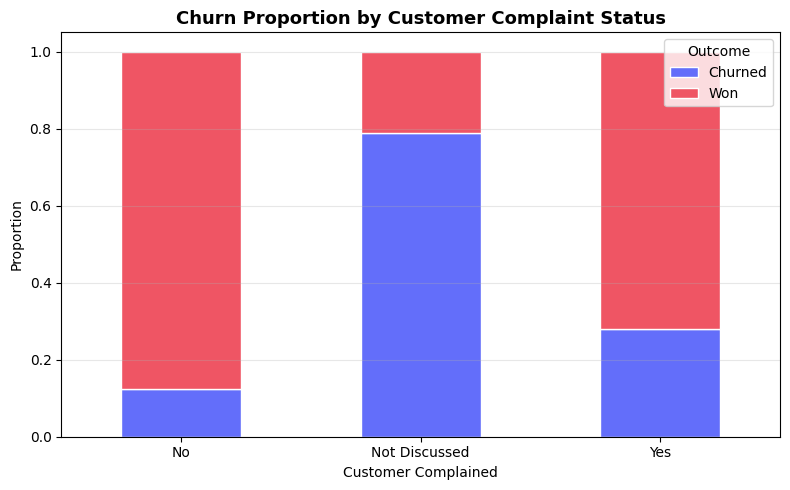

In [16]:
col = 'crm_customer_complained'
ct = pd.crosstab(merged_df[col], merged_df['Prospect_Outcome'])
chi2, p_value, _, _ = chi2_contingency(ct)
v = cramers_v(merged_df[col], merged_df['Prospect_Outcome'])

print('Contingency Table:')
print(ct)
print(f'\nChi-squared = {chi2:.2f} | p-value = {p_value:.4e} | Cramer\'s V = {v:.4f}')
print('Conclusion:', 'Reject H₀ — significant association found.' if p_value < 0.05 else 'Fail to reject H₀.')

# Normalised stacked bar (proportion-based)
ct_prop = ct.div(ct.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(8, 5))
ct_prop.plot(kind='bar', stacked=True, ax=ax, color=[BLUE, PINK], edgecolor='white')
ax.set_title('Churn Proportion by Customer Complaint Status', fontweight='bold', fontsize=13)
ax.set_xlabel('Customer Complained')
ax.set_ylabel('Proportion')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Outcome')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## **Output for Hypothesis 2 (Customer Complained → Higher Churn)**

### Key Findings
The normalised stacked bar chart shows the **proportion** of Won vs. Churned within each complaint category, making churn rates comparable even when group sizes differ significantly.

### Statistical Tests
| Test | Statistic | p-value | Cramer's V |
|---|---|---|---|
| Chi-square | *(see output)* | *(see output)* | *(see output)* |

### Conclusion
A complaint is a leading indicator of dissatisfaction. If Cramer's V > 0.1, this feature carries practical value for churn prediction.

### Business Implication
Complaint records should trigger an immediate retention workflow. Proactive resolution before the renewal date significantly reduces churn risk.

# **Hypothesis 3: Delays in Accreditation → Higher Churn**

**H₀:** There is no association between accreditation delays and churn.  
**Hₐ:** Contractors experiencing accreditation delays are more likely to churn.

Contingency Table:
Prospect_Outcome             Churned    Won
crm_delays_in_accreditation                
0                                 25    810
1                               6883  28121

Chi-squared = 144.57 | p-value = 2.6629e-33 | Cramer's V = 0.0448
Conclusion: Reject H₀ — significant association found.


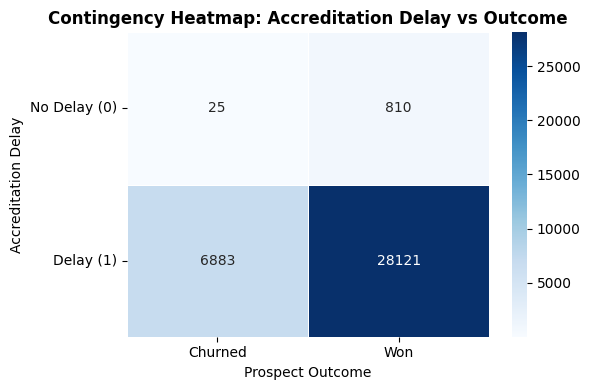

In [17]:
col = 'crm_delays_in_accreditation'
ct = pd.crosstab(merged_df[col], merged_df['Prospect_Outcome'])
chi2, p_value, _, _ = chi2_contingency(ct)
v = cramers_v(merged_df[col], merged_df['Prospect_Outcome'])

print('Contingency Table:')
print(ct)
print(f'\nChi-squared = {chi2:.2f} | p-value = {p_value:.4e} | Cramer\'s V = {v:.4f}')
print('Conclusion:', 'Reject H₀ — significant association found.' if p_value < 0.05 else 'Fail to reject H₀.')

# Heatmap of the contingency table
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Contingency Heatmap: Accreditation Delay vs Outcome', fontweight='bold', fontsize=12)
ax.set_xlabel('Prospect Outcome')
ax.set_ylabel('Accreditation Delay')
ax.set_yticklabels(['No Delay (0)', 'Delay (1)'], rotation=0)
plt.tight_layout()
plt.show()

## **Output for Hypothesis 3 (Delays in Accreditation → Higher Churn)**

### Key Findings
The heatmap provides an intuitive view of the joint distribution — darker cells indicate higher counts. A heavier Churned cell in the Delay row confirms that operational friction drives non-renewal.

### Statistical Tests
| Test | Statistic | p-value | Cramer's V |
|---|---|---|---|
| Chi-square | *(see output)* | *(see output)* | *(see output)* |

### Conclusion
Accreditation delays reflect operational friction. If the effect size is meaningful, this engineered feature provides value as a predictor beyond what individual raw columns offer.

### Business Implication
Contractors stuck in the accreditation pipeline need proactive support. Unresolved compliance issues correlate with disengagement and non-renewal.

# **Hypothesis 4: Contractor Engagement → Higher Churn**

**H₀:** There is no association between contractor engagement level and churn.  
**Hₐ:** Disengaged contractors are more likely to churn.

Contingency Table:
Prospect_Outcome           Churned    Won
crm_contractor_engagement                
0                             1321  15519
1                             5587  13412

Chi-squared = 2666.13 | p-value = 0.0000e+00 | Cramer's V = 0.1928
Conclusion: Reject H₀ — significant association found.


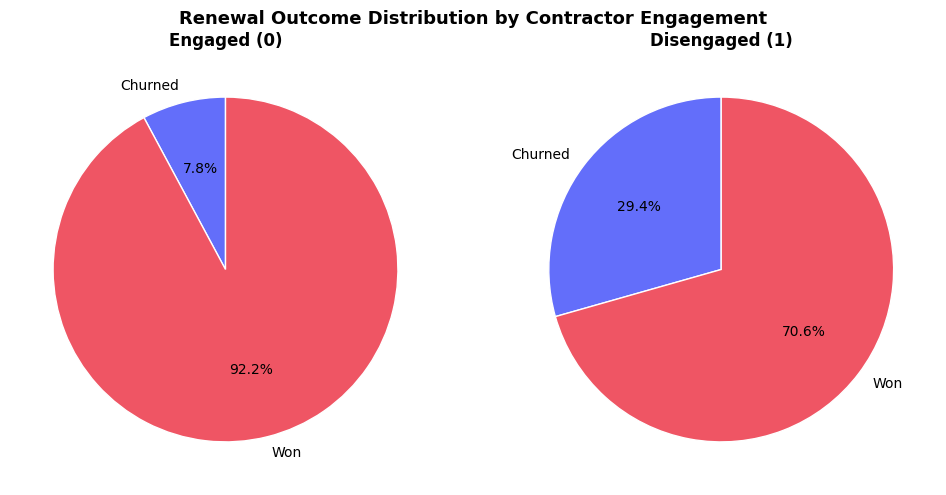

In [18]:
col = 'crm_contractor_engagement'
ct = pd.crosstab(merged_df[col], merged_df['Prospect_Outcome'])
chi2, p_value, _, _ = chi2_contingency(ct)
v = cramers_v(merged_df[col], merged_df['Prospect_Outcome'])

print('Contingency Table:')
print(ct)
print(f'\nChi-squared = {chi2:.2f} | p-value = {p_value:.4e} | Cramer\'s V = {v:.4f}')
print('Conclusion:', 'Reject H₀ — significant association found.' if p_value < 0.05 else 'Fail to reject H₀.')

# Pie charts side by side for each engagement group
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
group_labels = ['Engaged (0)', 'Disengaged (1)']
for i, ax in enumerate(axes):
    if i < len(ct):
        row = ct.iloc[i]
        ax.pie(row, labels=row.index, autopct='%1.1f%%', colors=[BLUE, PINK],
               startangle=90, wedgeprops=dict(edgecolor='white'))
        ax.set_title(group_labels[i], fontweight='bold')
fig.suptitle('Renewal Outcome Distribution by Contractor Engagement', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## **Output for Hypothesis 4 (Contractor Engagement → Higher Churn)**

### Key Findings
Side-by-side pie charts make the churn-rate difference between engaged and disengaged contractors immediately visible. A larger Churned slice in the Disengaged pie confirms the hypothesis directionally.

### Statistical Tests
| Test | Statistic | p-value | Cramer's V |
|---|---|---|---|
| Chi-square | *(see output)* | *(see output)* | *(see output)* |

### Conclusion
Contractor engagement is a composite behavioural signal. If significant, this feature should be prioritised in the retention model as an early warning indicator.

### Business Implication
Disengaged contractors require immediate re-engagement outreach before their renewal date arrives.

# **Hypothesis 5: Dissatisfaction with Support → Higher Churn**

**H₀:** There is no association between support dissatisfaction and churn.  
**Hₐ:** Customers dissatisfied with support are more likely to churn.

Contingency Table:
Prospect_Outcome                  Churned    Won
crm_dissatisfaction_with_support                
0                                    6127  27238
1                                     781   1693

Chi-squared = 257.25 | p-value = 6.8083e-58 | Cramer's V = 0.0598
Conclusion: Reject H₀ — significant association found.


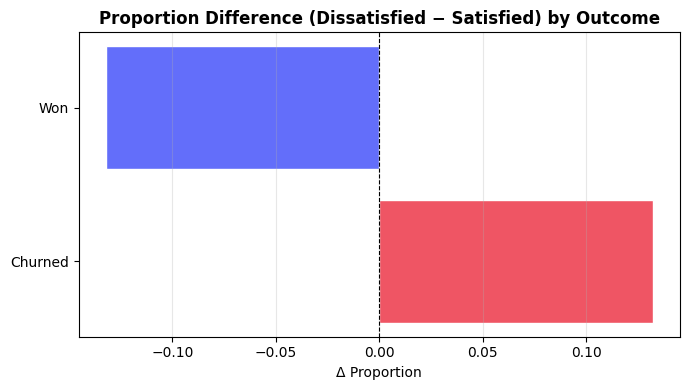

In [19]:
col = 'crm_dissatisfaction_with_support'
ct = pd.crosstab(merged_df[col], merged_df['Prospect_Outcome'])
chi2, p_value, _, _ = chi2_contingency(ct)
v = cramers_v(merged_df[col], merged_df['Prospect_Outcome'])

print('Contingency Table:')
print(ct)
print(f'\nChi-squared = {chi2:.2f} | p-value = {p_value:.4e} | Cramer\'s V = {v:.4f}')
print('Conclusion:', 'Reject H₀ — significant association found.' if p_value < 0.05 else 'Fail to reject H₀.')

# Diverging bar chart: difference in churn proportions
ct_prop = ct.div(ct.sum(axis=1), axis=0)
diff = ct_prop.iloc[1] - ct_prop.iloc[0]   # Dissatisfied minus Satisfied
fig, ax = plt.subplots(figsize=(7, 4))
colors = [PINK if val > 0 else BLUE for val in diff.values]
ax.barh(diff.index, diff.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Proportion Difference (Dissatisfied − Satisfied) by Outcome',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Δ Proportion')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## **Output for Hypothesis 5 (Dissatisfaction with Support → Higher Churn)**

### Key Findings
The diverging bar chart shows the **difference in outcome proportions** between dissatisfied and satisfied customers. A positive delta for Churned confirms that dissatisfied customers churn at a meaningfully higher rate.

### Statistical Tests
| Test | Statistic | p-value | Cramer's V |
|---|---|---|---|
| Chi-square | *(see output)* | *(see output)* | *(see output)* |

### Conclusion
Support dissatisfaction — a composite of negative experience, financial hardship, and explicit dissatisfaction flags — is a strong early churn signal.

### Business Implication
Customers who report support issues should be escalated to senior retention agents. Resolving these complaints before renewal significantly improves Win rates.

# **Hypothesis 6: Time to Renewal → Association with Churn**

**H₀:** There is no association between time-to-renewal bucket and churn.  
**Hₐ:** The timing of customer interactions relative to the renewal date is associated with churn likelihood.

Contingency Table:
Prospect_Outcome  Churned    Won
Time_to_Renewal                 
14_out               2955  21291
45_out                578   4539
Not Discussed        2791    510
pre_renewal           503   1714
prior_year             81    877

Chi-squared = 10120.14 | p-value = 0.0000e+00 | Cramer's V = 0.3757
Conclusion: Reject H₀ — significant association found.


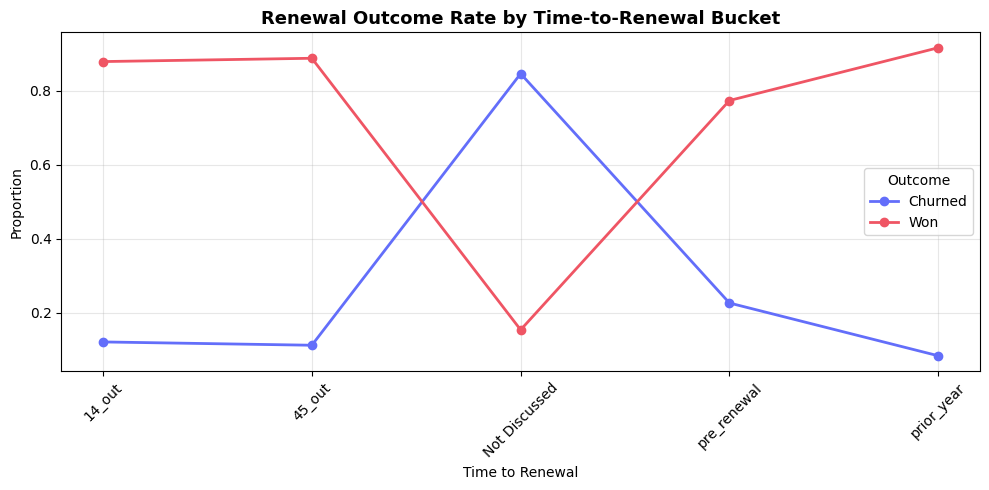

In [20]:
col = 'Time_to_Renewal'
ct = pd.crosstab(merged_df[col], merged_df['Prospect_Outcome'])
chi2, p_value, _, _ = chi2_contingency(ct)
v = cramers_v(merged_df[col], merged_df['Prospect_Outcome'])

print('Contingency Table:')
print(ct)
print(f'\nChi-squared = {chi2:.2f} | p-value = {p_value:.4e} | Cramer\'s V = {v:.4f}')
print('Conclusion:', 'Reject H₀ — significant association found.' if p_value < 0.05 else 'Fail to reject H₀.')

# Line plot of churn rate across Time_to_Renewal buckets
ct_prop = ct.div(ct.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(10, 5))
for outcome, color in zip(ct_prop.columns, [BLUE, PINK]):
    ax.plot(ct_prop.index, ct_prop[outcome], marker='o', label=outcome,
            color=color, linewidth=2)
ax.set_title('Renewal Outcome Rate by Time-to-Renewal Bucket', fontweight='bold', fontsize=13)
ax.set_xlabel('Time to Renewal')
ax.set_ylabel('Proportion')
ax.legend(title='Outcome')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Output for Hypothesis 6 (Time to Renewal → Association with Churn)**

### Key Findings
The line chart traces how the Won and Churned proportions shift across time-to-renewal buckets. Crossovers or sharp divergences pinpoint the most critical intervention windows.

### Statistical Tests
| Test | Statistic | p-value | Cramer's V |
|---|---|---|---|
| Chi-square | *(see output)* | *(see output)* | *(see output)* |

### Conclusion
If certain time windows show elevated churn proportions, outreach should be concentrated in those buckets to maximise retention impact.

### Business Implication
Knowing which time-to-renewal bracket carries the highest churn risk allows the retention team to prioritise call scheduling and resource allocation more effectively.

# **Hypothesis 7: Competitors Mentioned → Higher Churn**

**H₀:** There is no association between competitor mentions and churn.  
**Hₐ:** Customers who mentioned competitors are more likely to churn.

Contingency Table:
Prospect_Outcome           Churned    Won
crm_competitors_mentioned                
No                            3565  22675
Not Discussed                 3289   6092
Yes                             54    164

Chi-squared = 2052.27 | p-value = 0.0000e+00 | Cramer's V = 0.1691
Conclusion: Reject H₀ — significant association found.


C:\Users\ilakk\AppData\Local\Temp\ipykernel_20252\1450906167.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)


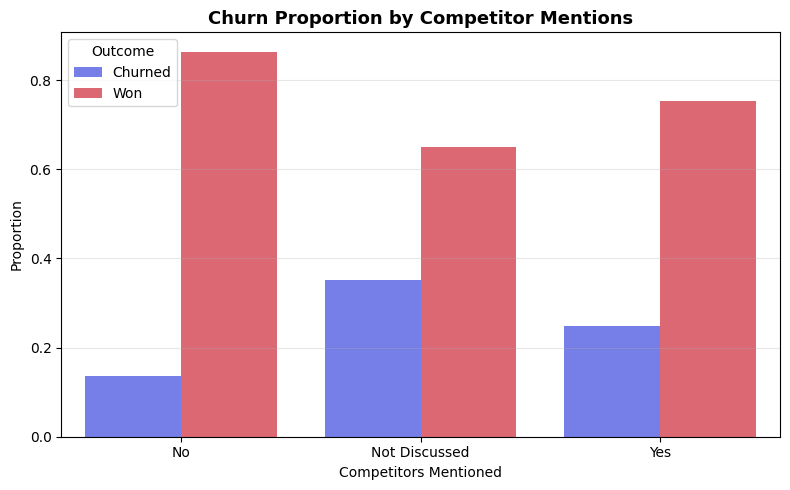

In [21]:
col = 'crm_competitors_mentioned'
ct = pd.crosstab(merged_df[col], merged_df['Prospect_Outcome'])
chi2, p_value, _, _ = chi2_contingency(ct)
v = cramers_v(merged_df[col], merged_df['Prospect_Outcome'])

print('Contingency Table:')
print(ct)
print(f'\nChi-squared = {chi2:.2f} | p-value = {p_value:.4e} | Cramer\'s V = {v:.4f}')
print('Conclusion:', 'Reject H₀ — significant association found.' if p_value < 0.05 else 'Fail to reject H₀.')

# Grouped proportion bar using seaborn
ct_prop = ct.div(ct.sum(axis=1), axis=0).reset_index()
ct_melted = ct_prop.melt(id_vars=col, var_name='Outcome', value_name='Proportion')
outcomes = ct_melted['Outcome'].unique()
palette = {outcomes[0]: BLUE, outcomes[1]: PINK}
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=ct_melted, x=col, y='Proportion', hue='Outcome',
            palette=palette, ax=ax)
ax.set_title('Churn Proportion by Competitor Mentions', fontweight='bold', fontsize=13)
ax.set_xlabel('Competitors Mentioned')
ax.set_ylabel('Proportion')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## **Output for Hypothesis 7 (Competitors Mentioned → Higher Churn)**

### Key Findings
The grouped proportion bar chart compares Won vs. Churned rates across each competitor-mention category without being distorted by group-size imbalance.

### Statistical Tests
| Test | Statistic | p-value | Cramer's V |
|---|---|---|---|
| Chi-square | *(see output)* | *(see output)* | *(see output)* |

### Conclusion
Even if the p-value is significant, a small Cramer's V (< 0.1) indicates that competitor mentions alone are not a strong enough signal to drive model predictions.

### Business Implication
If the effect is meaningful, customers who raise competitor names should be flagged for a targeted value-proposition response — price matching, feature comparisons, or exclusive offers.

# **Hypothesis 8: Customer Payment Intention → Higher Churn**

**H₀:** There is no association between engineered payment intention and churn.  
**Hₐ:** Customers showing payment reluctance are more likely to churn.

Contingency Table:
Prospect_Outcome                Churned    Won
crm_customer_payment_intention                
0                                  5683  27695
1                                  1225   1236

Chi-squared = 1577.85 | p-value = 0.0000e+00 | Cramer's V = 0.1483
Conclusion: Reject H₀ — significant association found.


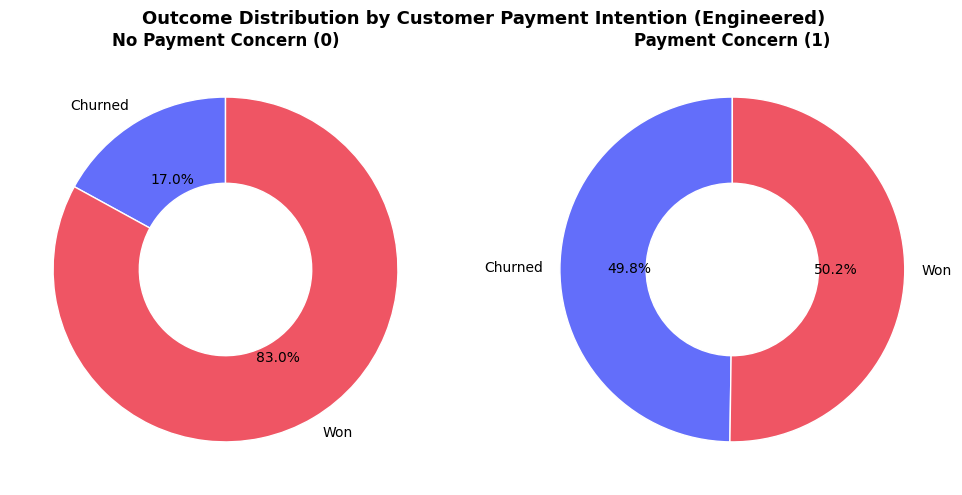

In [22]:
col = 'crm_customer_payment_intention'
ct = pd.crosstab(merged_df[col], merged_df['Prospect_Outcome'])
chi2, p_value, _, _ = chi2_contingency(ct)
v = cramers_v(merged_df[col], merged_df['Prospect_Outcome'])

print('Contingency Table:')
print(ct)
print(f'\nChi-squared = {chi2:.2f} | p-value = {p_value:.4e} | Cramer\'s V = {v:.4f}')
print('Conclusion:', 'Reject H₀ — significant association found.' if p_value < 0.05 else 'Fail to reject H₀.')

# Donut charts side by side for each payment group
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
titles = ['No Payment Concern (0)', 'Payment Concern (1)']
for i, ax in enumerate(axes):
    if i < len(ct):
        row = ct.iloc[i]
        wedges, texts, autotexts = ax.pie(
            row, labels=row.index, autopct='%1.1f%%',
            colors=[BLUE, PINK], startangle=90,
            wedgeprops=dict(width=0.5, edgecolor='white')
        )
        ax.set_title(titles[i], fontweight='bold')
fig.suptitle('Outcome Distribution by Customer Payment Intention (Engineered)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## **Output for Hypothesis 8 (Customer Payment Intention → Higher Churn)**

### Key Findings
Donut charts compare the outcome composition for customers flagged with payment concerns (1) vs. those without (0). A visibly larger Churned segment in the concern group confirms the hypothesis directionally.

### Statistical Tests
| Test | Statistic | p-value | Cramer's V |
|---|---|---|---|
| Chi-square | *(see output)* | *(see output)* | *(see output)* |

### Conclusion
Payment reluctance — combining price dissatisfaction and stated payment intention — is a financially grounded churn indicator.

### Business Implication
Customers flagged with payment concerns should receive early discount or payment-plan conversations, rather than waiting until the renewal invoice is issued.

# **Hypothesis 9: Agent Chase Flag → Higher Churn**

**H₀:** There is no association between the agent chase flag and churn.  
**Hₐ:** Customers requiring repeated agent chasing are more likely to churn.

Contingency Table:
Prospect_Outcome      Churned    Won
crm_agent_chase_flag                
0                        6088  25546
1                         820   3385

Chi-squared = 0.14 | p-value = 7.0857e-01 | Cramer's V = 0.0000
Conclusion: Fail to reject H₀.


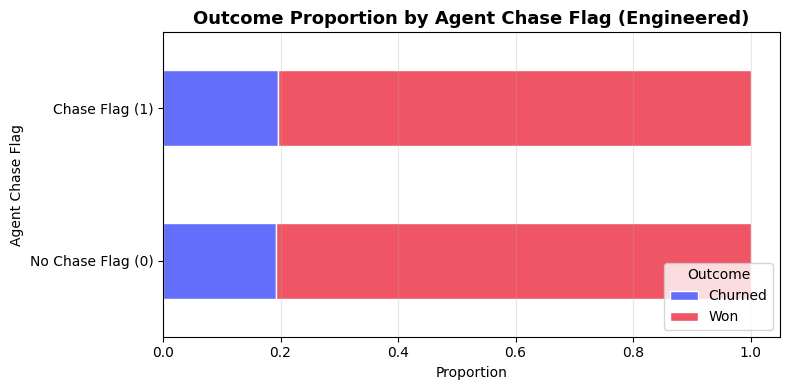

In [23]:
col = 'crm_agent_chase_flag'
ct = pd.crosstab(merged_df[col], merged_df['Prospect_Outcome'])
chi2, p_value, _, _ = chi2_contingency(ct)
v = cramers_v(merged_df[col], merged_df['Prospect_Outcome'])

print('Contingency Table:')
print(ct)
print(f'\nChi-squared = {chi2:.2f} | p-value = {p_value:.4e} | Cramer\'s V = {v:.4f}')
print('Conclusion:', 'Reject H₀ — significant association found.' if p_value < 0.05 else 'Fail to reject H₀.')

# Horizontal stacked bar chart
ct_prop = ct.div(ct.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(8, 4))
ct_prop.plot(kind='barh', stacked=True, ax=ax, color=[BLUE, PINK], edgecolor='white')
ax.set_title('Outcome Proportion by Agent Chase Flag (Engineered)', fontweight='bold', fontsize=13)
ax.set_xlabel('Proportion')
ax.set_ylabel('Agent Chase Flag')
ax.set_yticklabels(['No Chase Flag (0)', 'Chase Flag (1)'], rotation=0)
ax.legend(title='Outcome', loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## **Output for Hypothesis 9 (Agent Chase Flag → Higher Churn)**

### Key Findings
The horizontal stacked bar chart shows the proportion of Won vs. Churned for contractors that required heavy agent chasing (1) versus those who did not (0). A higher Churned segment on the flag = 1 bar confirms the hypothesis.

### Statistical Tests
| Test | Statistic | p-value | Cramer's V |
|---|---|---|---|
| Chi-square | *(see output)* | *(see output)* | *(see output)* |

### Conclusion
Repeated agent follow-up (more than twice) signals contractor unresponsiveness — a behaviour pattern associated with disengagement and eventual non-renewal.

### Business Implication
Automatically flagging contractors who require more than two chases allows the team to route these accounts to specialist retention agents earlier in the renewal cycle.

# Cramer's V Correlation Heatmap

To validate individual hypothesis results and identify multicollinearity before modelling, we compute **pairwise Cramer's V** across all selected categorical features (including the target `Prospect_Outcome`).

- High V values between two **predictor** features indicate redundancy — only one needs to enter the model.
- High V values between a **predictor** and `Prospect_Outcome` confirm strong churn association.

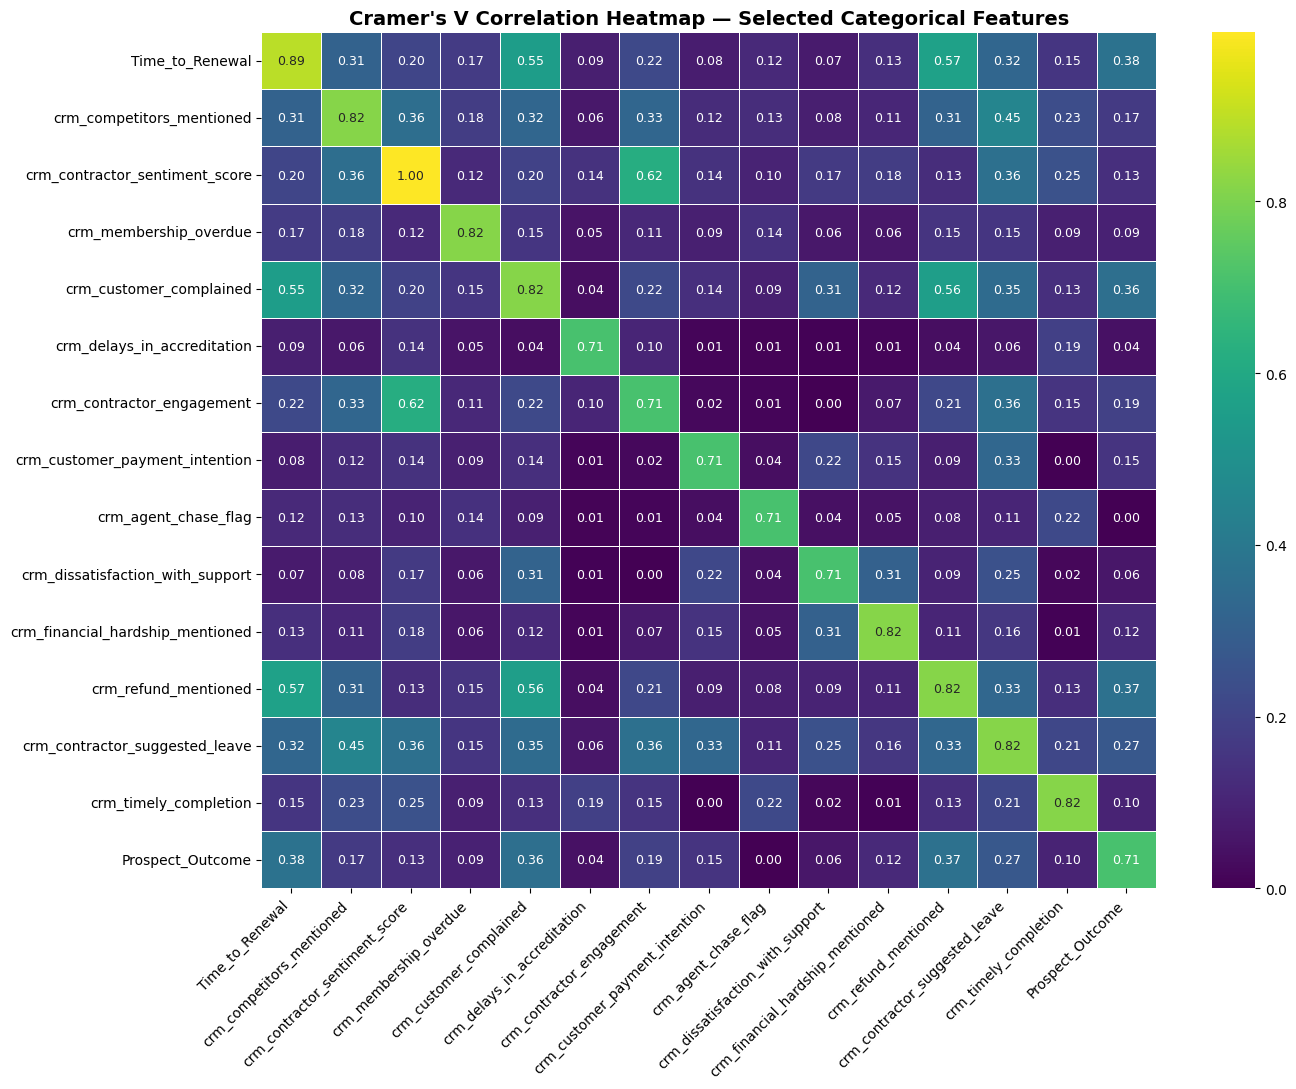

In [24]:
selected_categorical_features = [
    'Time_to_Renewal',
    'crm_competitors_mentioned',
    'crm_contractor_sentiment_score',
    'crm_membership_overdue',
    'crm_customer_complained',
    'crm_delays_in_accreditation',
    'crm_contractor_engagement',
    'crm_customer_payment_intention',
    'crm_agent_chase_flag',
    'crm_dissatisfaction_with_support',
    'crm_financial_hardship_mentioned',
    'crm_refund_mentioned',
    'crm_contractor_suggested_leave',
    'crm_timely_completion',
    'Prospect_Outcome'
]

df_for_correlation = merged_df[selected_categorical_features].copy()

cramers_v_matrix = pd.DataFrame(
    index=selected_categorical_features,
    columns=selected_categorical_features,
    dtype=float
)

for col1 in selected_categorical_features:
    for col2 in selected_categorical_features:
        cramers_v_matrix.loc[col1, col2] = cramers_v(
            df_for_correlation[col1], df_for_correlation[col2]
        )

plt.figure(figsize=(14, 11))
sns.heatmap(
    cramers_v_matrix.astype(float),
    annot=True, fmt='.2f', cmap='viridis',
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}
)
plt.title("Cramer's V Correlation Heatmap \u2014 Selected Categorical Features",
          fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Feature Selection

Based on the hypothesis testing results and Cramer's V heatmap, features with a meaningful association with `Prospect_Outcome` (V > 0.1) are retained for modelling. Features showing multicollinearity with each other are reduced to avoid redundancy.

In [25]:
selected_features_for_model = [
    'Co_Ref',                               # Identifier
    'crm_customer_complained',              # Hypothesis 2
    'Time_to_Renewal',                      # Hypothesis 6
    'crm_competitors_mentioned',            # Hypothesis 7
    'crm_refund_mentioned',
    'crm_contractor_engagement',            # Hypothesis 4
    'crm_customer_payment_intention',       # Hypothesis 8
    'crm_membership_overdue',               # Hypothesis 1
    'crm_dissatisfaction_with_support',     # Hypothesis 5
    'crm_contractor_sentiment_score',
    'Prospect_Outcome'                      # Target
]

df_model_features = merged_df[selected_features_for_model].copy()

print(f'Shape of modelling DataFrame: {df_model_features.shape}')
display(df_model_features.head())

Shape of modelling DataFrame: (35839, 11)


,Co_Ref,crm_customer_complained,Time_to_Renewal,crm_competitors_mentioned,crm_refund_mentioned,crm_contractor_engagement,crm_customer_payment_intention,crm_membership_overdue,crm_dissatisfaction_with_support,crm_contractor_sentiment_score,Prospect_Outcome
0,AA0584,No,45_out,No,No,0,0,Not Discussed,0,50.000000,Won
1,AA0641,No,14_out,Not Discussed,No,1,0,Not Discussed,0,16.666667,Won
2,AA0784,No,14_out,Not Discussed,No,1,0,No,0,0.000000,Won
3,AA0794,No,14_out,No,No,1,1,Yes,0,16.666667,Won
4,AA0882,No,45_out,No,No,0,0,Not Discussed,0,50.000000,Won


# Encoding

Label encoding is applied to all remaining categorical columns before passing the data to a machine learning model. `Co_Ref` and `Prospect_Outcome` are excluded — the former is an identifier, and the latter is the target variable processed separately.

In [26]:
categorical_features_to_encode = [
    col for col in df_model_features.columns
    if df_model_features[col].dtype == 'object'
    and col not in ['Co_Ref', 'Prospect_Outcome']
]

print(f'Columns to label encode: {categorical_features_to_encode}')

for col in categorical_features_to_encode:
    le = LabelEncoder()
    df_model_features[col] = le.fit_transform(df_model_features[col])
    print(f"  Encoded '{col}' -> unique values: {sorted(df_model_features[col].unique())}")

print('\nFirst 5 rows after Label Encoding:')
display(df_model_features.head())
print('\nData types:')
print(df_model_features.dtypes)

Columns to label encode: []

First 5 rows after Label Encoding:


,Co_Ref,crm_customer_complained,Time_to_Renewal,crm_competitors_mentioned,crm_refund_mentioned,crm_contractor_engagement,crm_customer_payment_intention,crm_membership_overdue,crm_dissatisfaction_with_support,crm_contractor_sentiment_score,Prospect_Outcome
0,AA0584,No,45_out,No,No,0,0,Not Discussed,0,50.000000,Won
1,AA0641,No,14_out,Not Discussed,No,1,0,Not Discussed,0,16.666667,Won
2,AA0784,No,14_out,Not Discussed,No,1,0,No,0,0.000000,Won
3,AA0794,No,14_out,No,No,1,1,Yes,0,16.666667,Won
4,AA0882,No,45_out,No,No,0,0,Not Discussed,0,50.000000,Won



Data types:
Co_Ref                                  str
crm_customer_complained                 str
Time_to_Renewal                         str
crm_competitors_mentioned               str
crm_refund_mentioned                    str
crm_contractor_engagement             int64
crm_customer_payment_intention        int64
crm_membership_overdue                  str
crm_dissatisfaction_with_support      int64
crm_contractor_sentiment_score      float64
Prospect_Outcome                        str
dtype: object


# Saving Data

In [27]:

output_path_folder = os.getenv("PROCESS_DATA_FOLDER")
df_model_features.to_csv(output_path_folder+PATH_SEP+"emails_processed.csv",index=False)